In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

Raw Data
   →
Data Understanding
   →
Data Quality Assessment
   →
Missing Value Handling
   →
Outlier Treatment
   →
Data Type Fixing
   →
Feature Encoding & Scaling
   →
Validation (Before vs After)
   →
Clean Dataset → ML Model

# Method 1 - Columns first then rows

In [3]:
df = pd.read_csv("train.csv")
df.shape

(1460, 81)

In [4]:
df_null_clm = df.isnull().sum().to_frame("null count")
df_null_clm["null percentage"] = df_null_clm["null count"] / df.shape[0] * 100
df_null_clm

,null count,null percentage
Id,0,0.000000
MSSubClass,0,0.000000
MSZoning,0,0.000000
LotFrontage,259,17.739726
LotArea,0,0.000000
Street,0,0.000000
Alley,1369,93.767123
LotShape,0,0.000000
LandContour,0,0.000000
Utilities,0,0.000000


In [5]:
df_null_per = df_null_clm[df_null_clm["null percentage"] > 20]
df_null_per

,null count,null percentage
Alley,1369,93.767123
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
PoolQC,1453,99.520548
Fence,1179,80.753425
MiscFeature,1406,96.301370


In [6]:
l = df_null_per.index
l

Index(['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature'], dtype='str')

In [7]:
df_drop_clm = df.drop(columns = l)
df_drop_clm.shape

(1460, 75)

In [8]:
df_num_clm = df_drop_clm.select_dtypes(include = ["int64", "float64"])
df_num_clm.shape

(1460, 38)

In [9]:
%matplotlib inline
plt.figure(figsize = (20,20))

<Figure size 2000x2000 with 0 Axes>

<Figure size 2000x2000 with 0 Axes>

<Axes: >

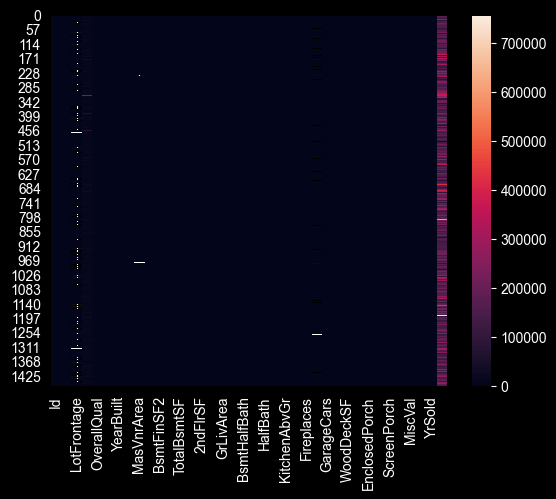

In [10]:
sns.heatmap(df_num_clm)

In [11]:
df_drop_row = df_num_clm.dropna()
df_drop_row.shape

(1121, 38)

<Axes: >

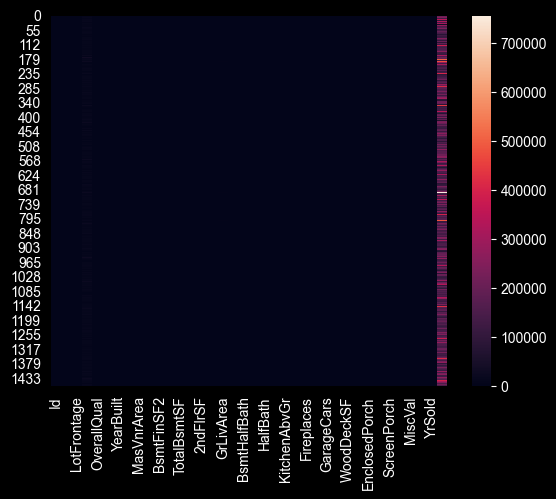

In [12]:
sns.heatmap(df_drop_row)

In [13]:
df_drop_row.columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')

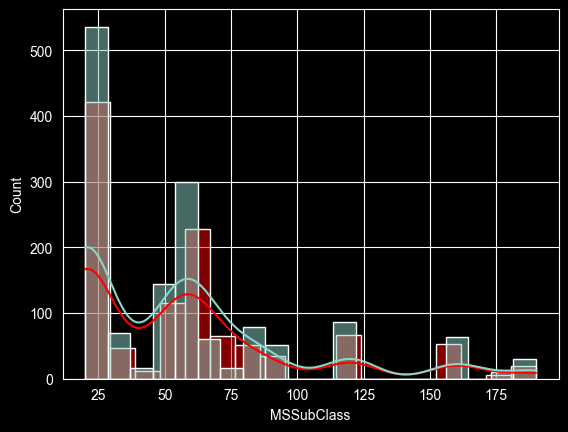

In [14]:
sns.histplot(df_drop_row["MSSubClass"], color = "red", kde = True)
sns.histplot(df["MSSubClass"], kde = True)
plt.show()

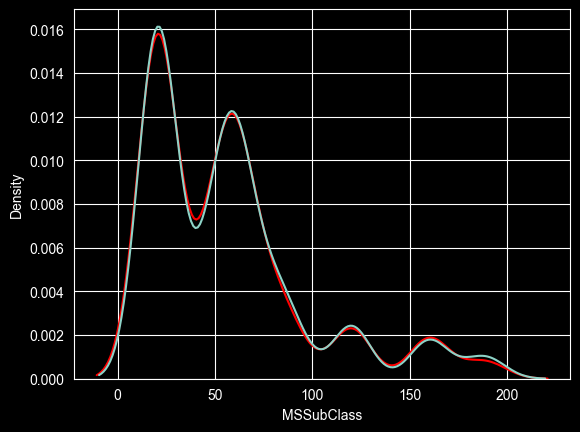

In [15]:
sns.kdeplot(df_drop_row["MSSubClass"], color = "red")
sns.kdeplot(df["MSSubClass"])
plt.show()

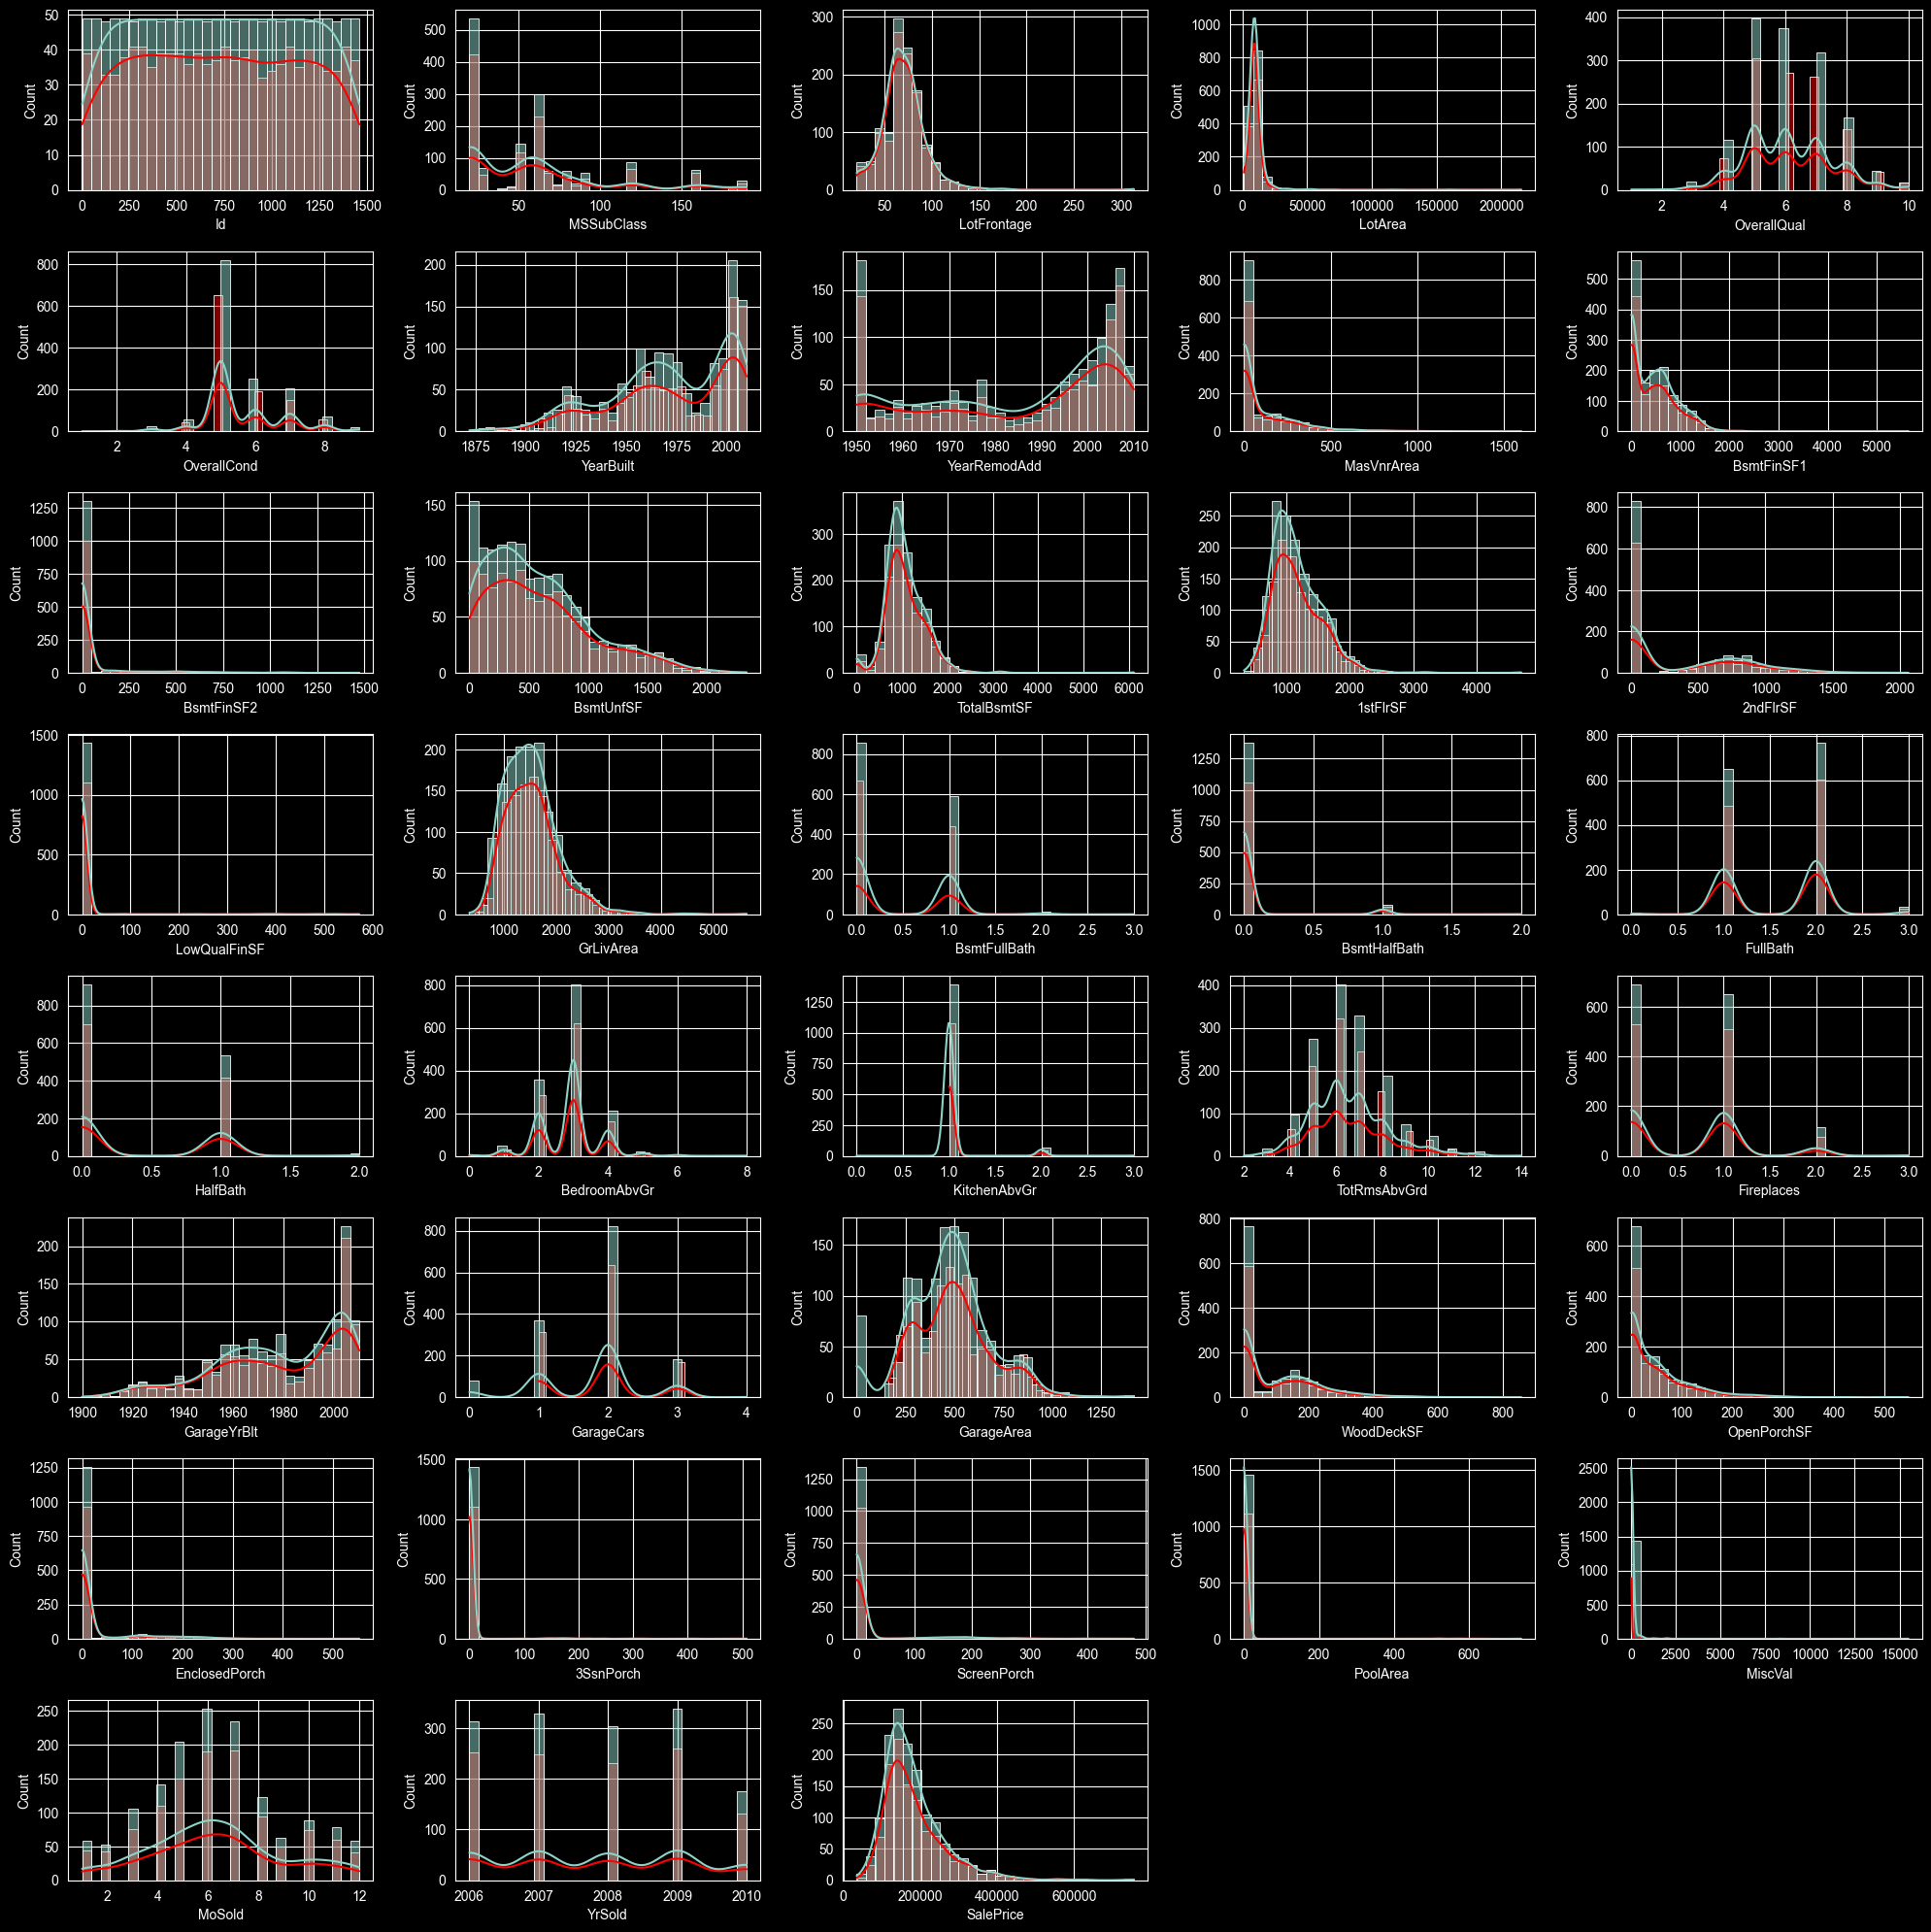

In [16]:
plt.figure(figsize = (20, 20))
for i, var in enumerate(df_drop_row):
    plt.subplot(8, 5, i+1)
    sns.histplot(df_drop_row[var], kde = True, bins = 30, color = "Red")
    sns.histplot(df[var], kde = True, bins = 30)
plt.tight_layout()
plt.savefig("Histplot visualization of cleaned data for 'train_csv' dataset on numeric columns")
plt.show()

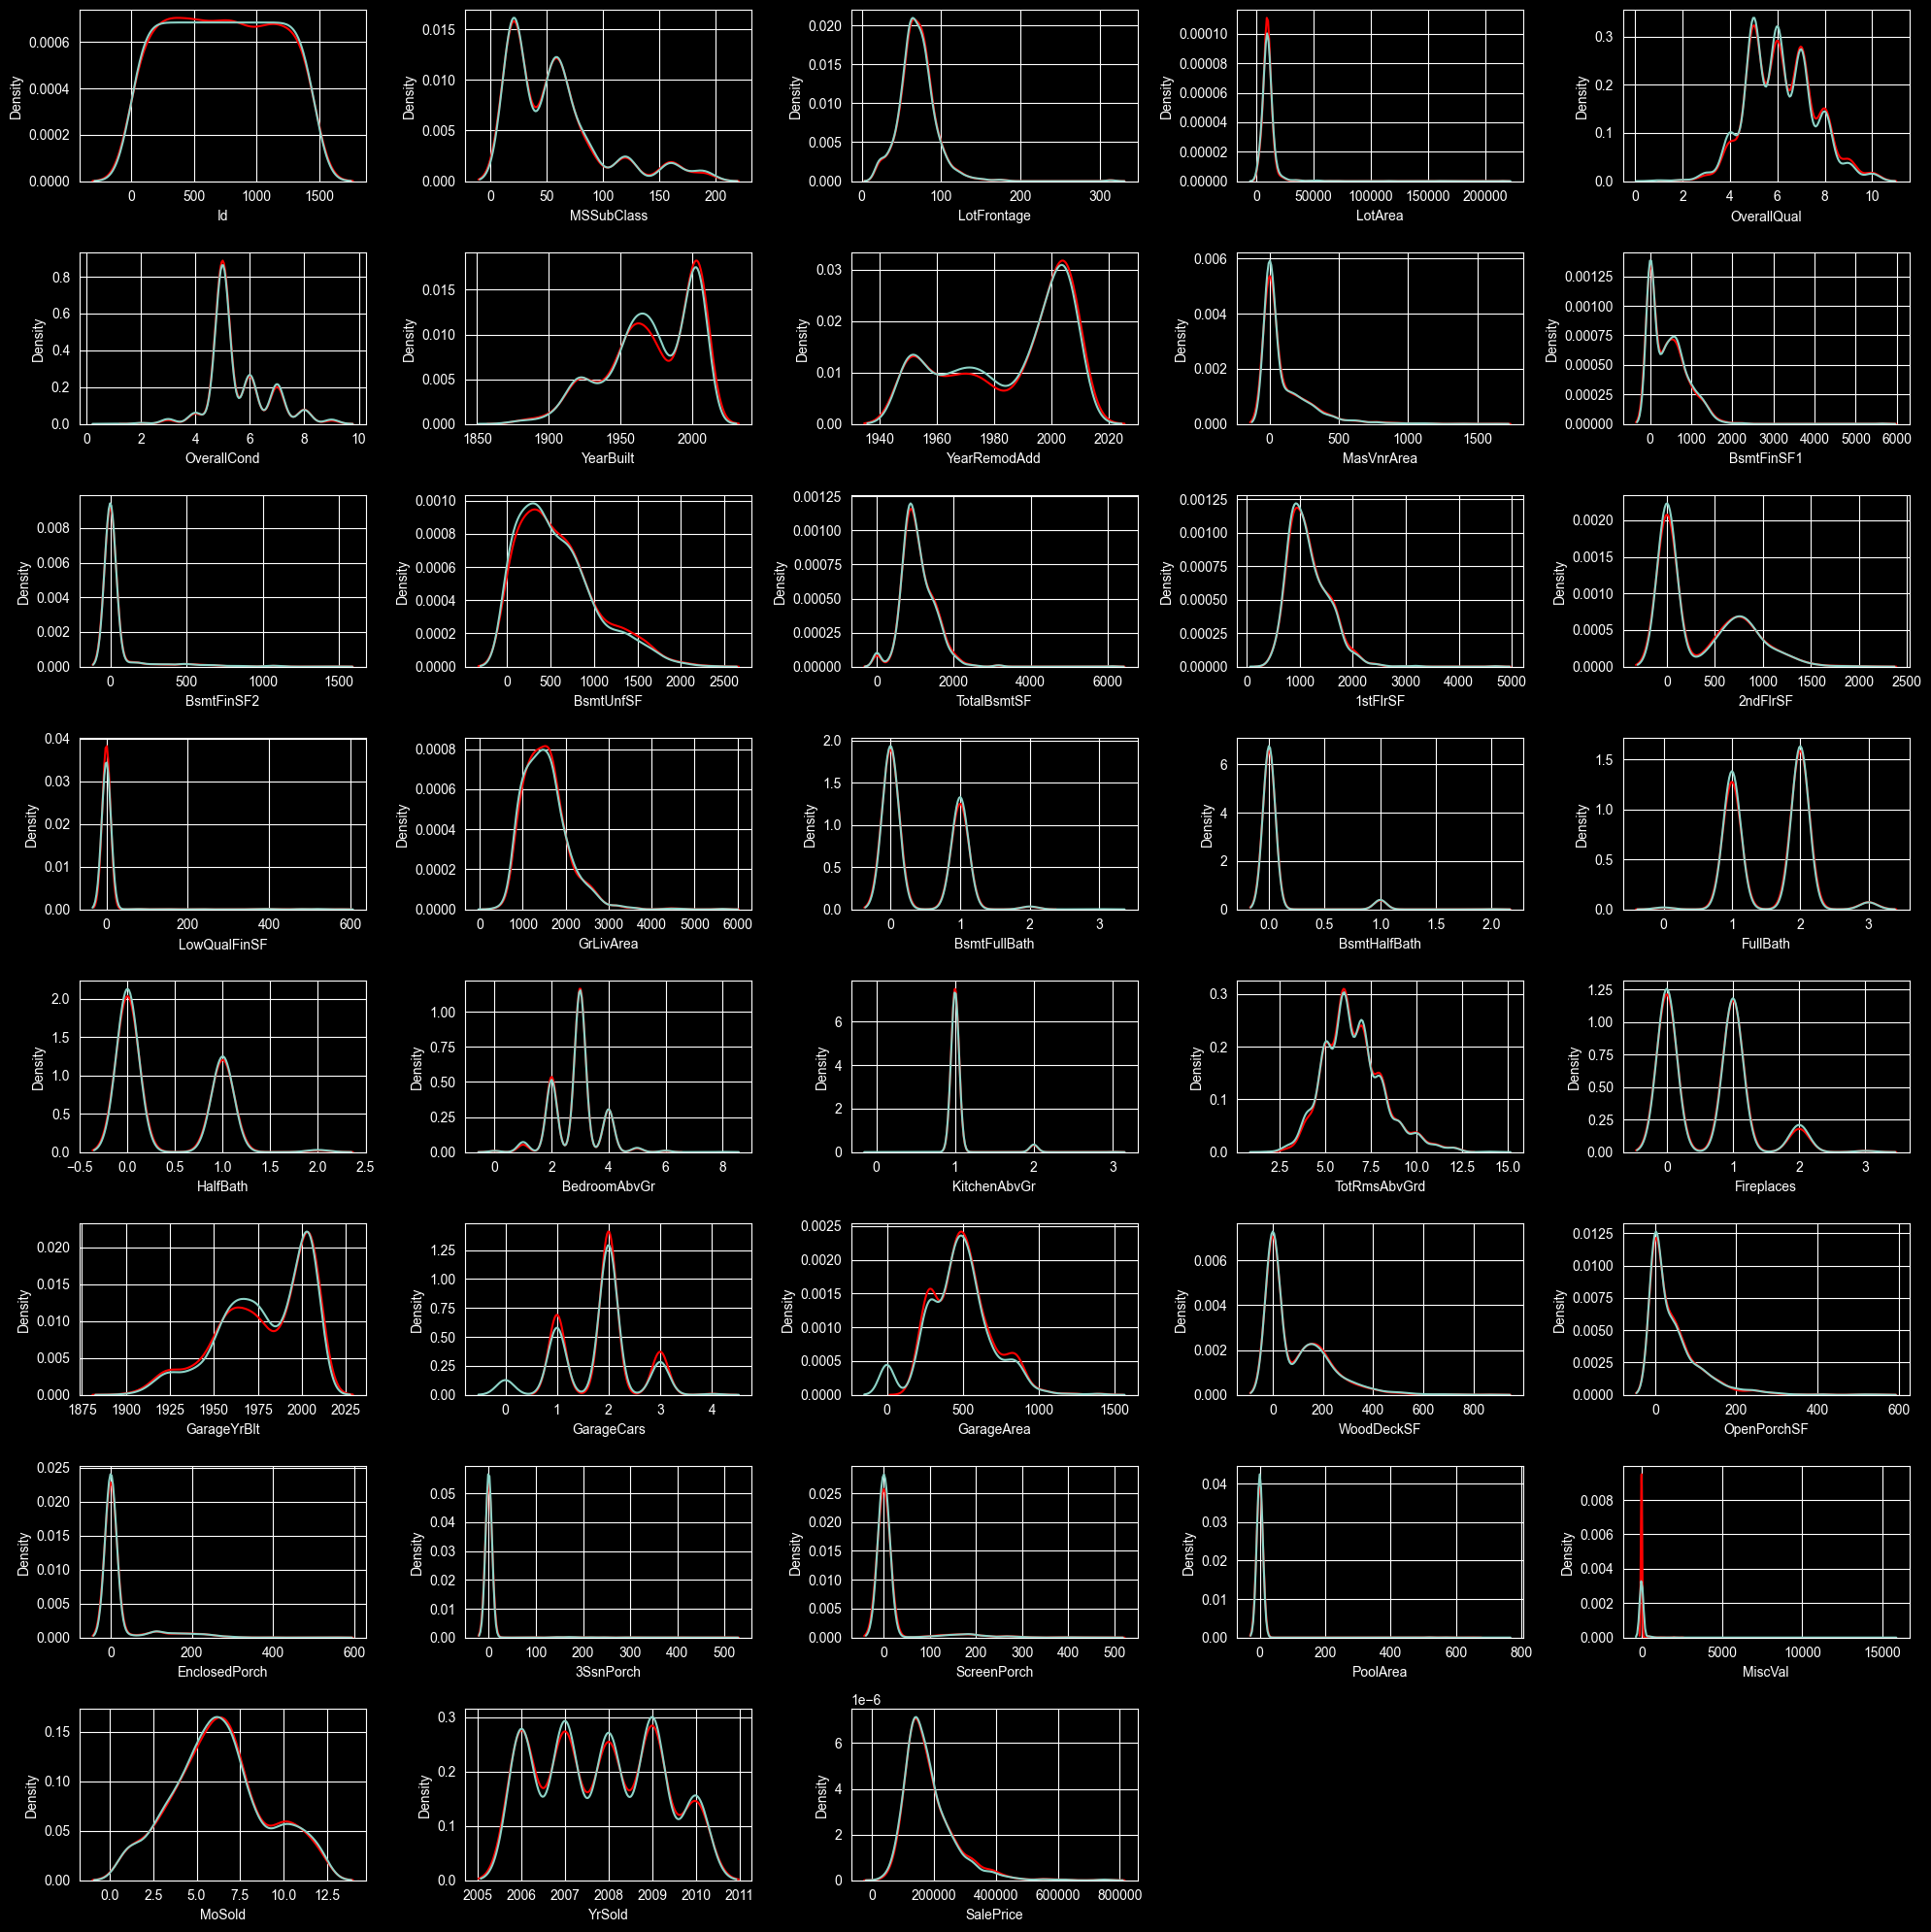

In [17]:
plt.figure(figsize = (20, 20))
for i, var in enumerate(df_drop_row):
    plt.subplot(8, 5, i+1)
    sns.kdeplot(df_drop_row[var], color = "Red")
    sns.kdeplot(df[var])
plt.tight_layout()
plt.savefig("Kdeplot visualization of cleaned data for 'train_csv' dataset on numeric columns")
plt.show()

Understand meaning → choose strategy → fill → standardize → validate

In [18]:
df_cat_clm = df_drop_clm.select_dtypes(include = ["object"])
df_cat_clm.shape

C:\Users\DHANANJAY\AppData\Local\Temp\ipykernel_24468\1297784729.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_cat_clm = df_drop_clm.select_dtypes(include = ["object"])


(1460, 37)

In [19]:
df_drop_clms = df_drop_clm.dropna()
df_drop_clms.shape

(1094, 75)

In [20]:
after = df_drop_clms["MSZoning"].value_counts() / df_drop_clms.shape[0] * 100

In [21]:
before = df["MSZoning"].value_counts() / df.shape[0] * 100

In [22]:
pd.concat([df_drop_clms["MSZoning"].value_counts() / df_drop_clms.shape[0] * 100, df["MSZoning"].value_counts() / df.shape[0] * 100], axis = 1, keys = ["after", "before"])

,after,before
MSZoning,,
RL,77.696527,78.835616
RM,15.813528,14.931507
FV,4.936015,4.452055
RH,0.822669,1.095890
C (all),0.731261,0.684932


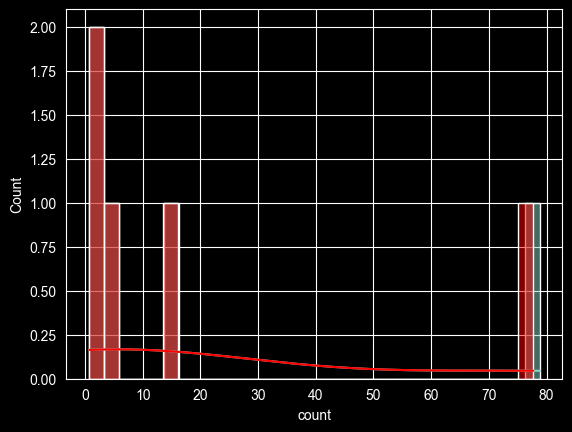

In [23]:
sns.histplot(before, bins = 30, legend = True, kde = True)
sns.histplot(after, bins = 30, color = "Red", legend = True, kde = True)
plt.show()

In [24]:
df_cat_clms = df_cat_clm.dropna()
df_cat_clms.shape

(1346, 37)

In [25]:
pd.concat([df_cat_clms["MSZoning"].value_counts() / df_cat_clms.shape[0] * 100, df["MSZoning"].value_counts() / df.shape[0] * 100], axis = 1, keys = ["After", "Before"])

,After,Before
MSZoning,,
RL,79.569094,78.835616
RM,14.190193,14.931507
FV,4.829123,4.452055
RH,0.817236,1.095890
C (all),0.594354,0.684932


In [26]:
After = df_cat_clms["MSZoning"].value_counts() / df_cat_clms.shape[0] * 100

In [27]:
Before = df["MSZoning"].value_counts() / df.shape[0] * 100

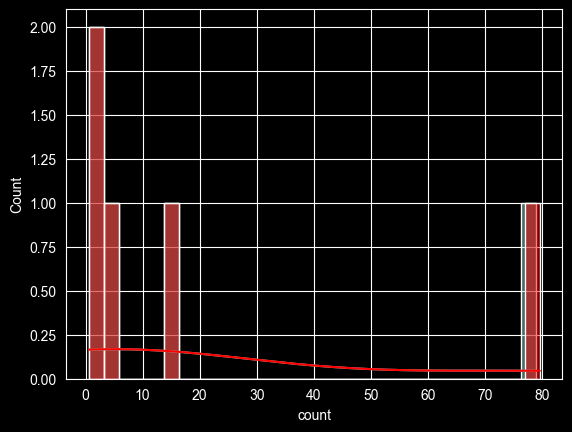

In [28]:
sns.histplot(Before, bins = 30, legend = True, kde = True)
sns.histplot(After, bins = 30, color = "Red", legend = True, kde = True)
plt.show()

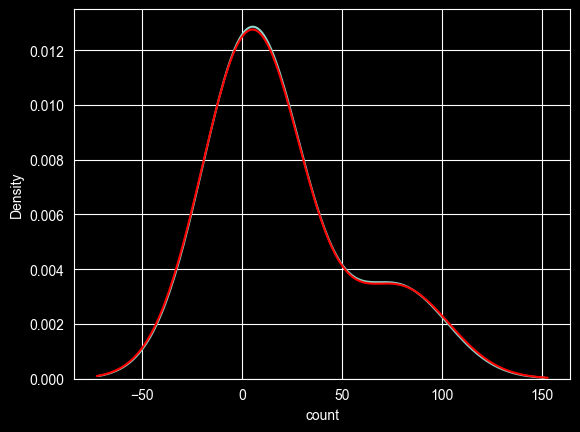

In [29]:
sns.kdeplot(Before)
sns.kdeplot(After, color = "Red")
plt.show()

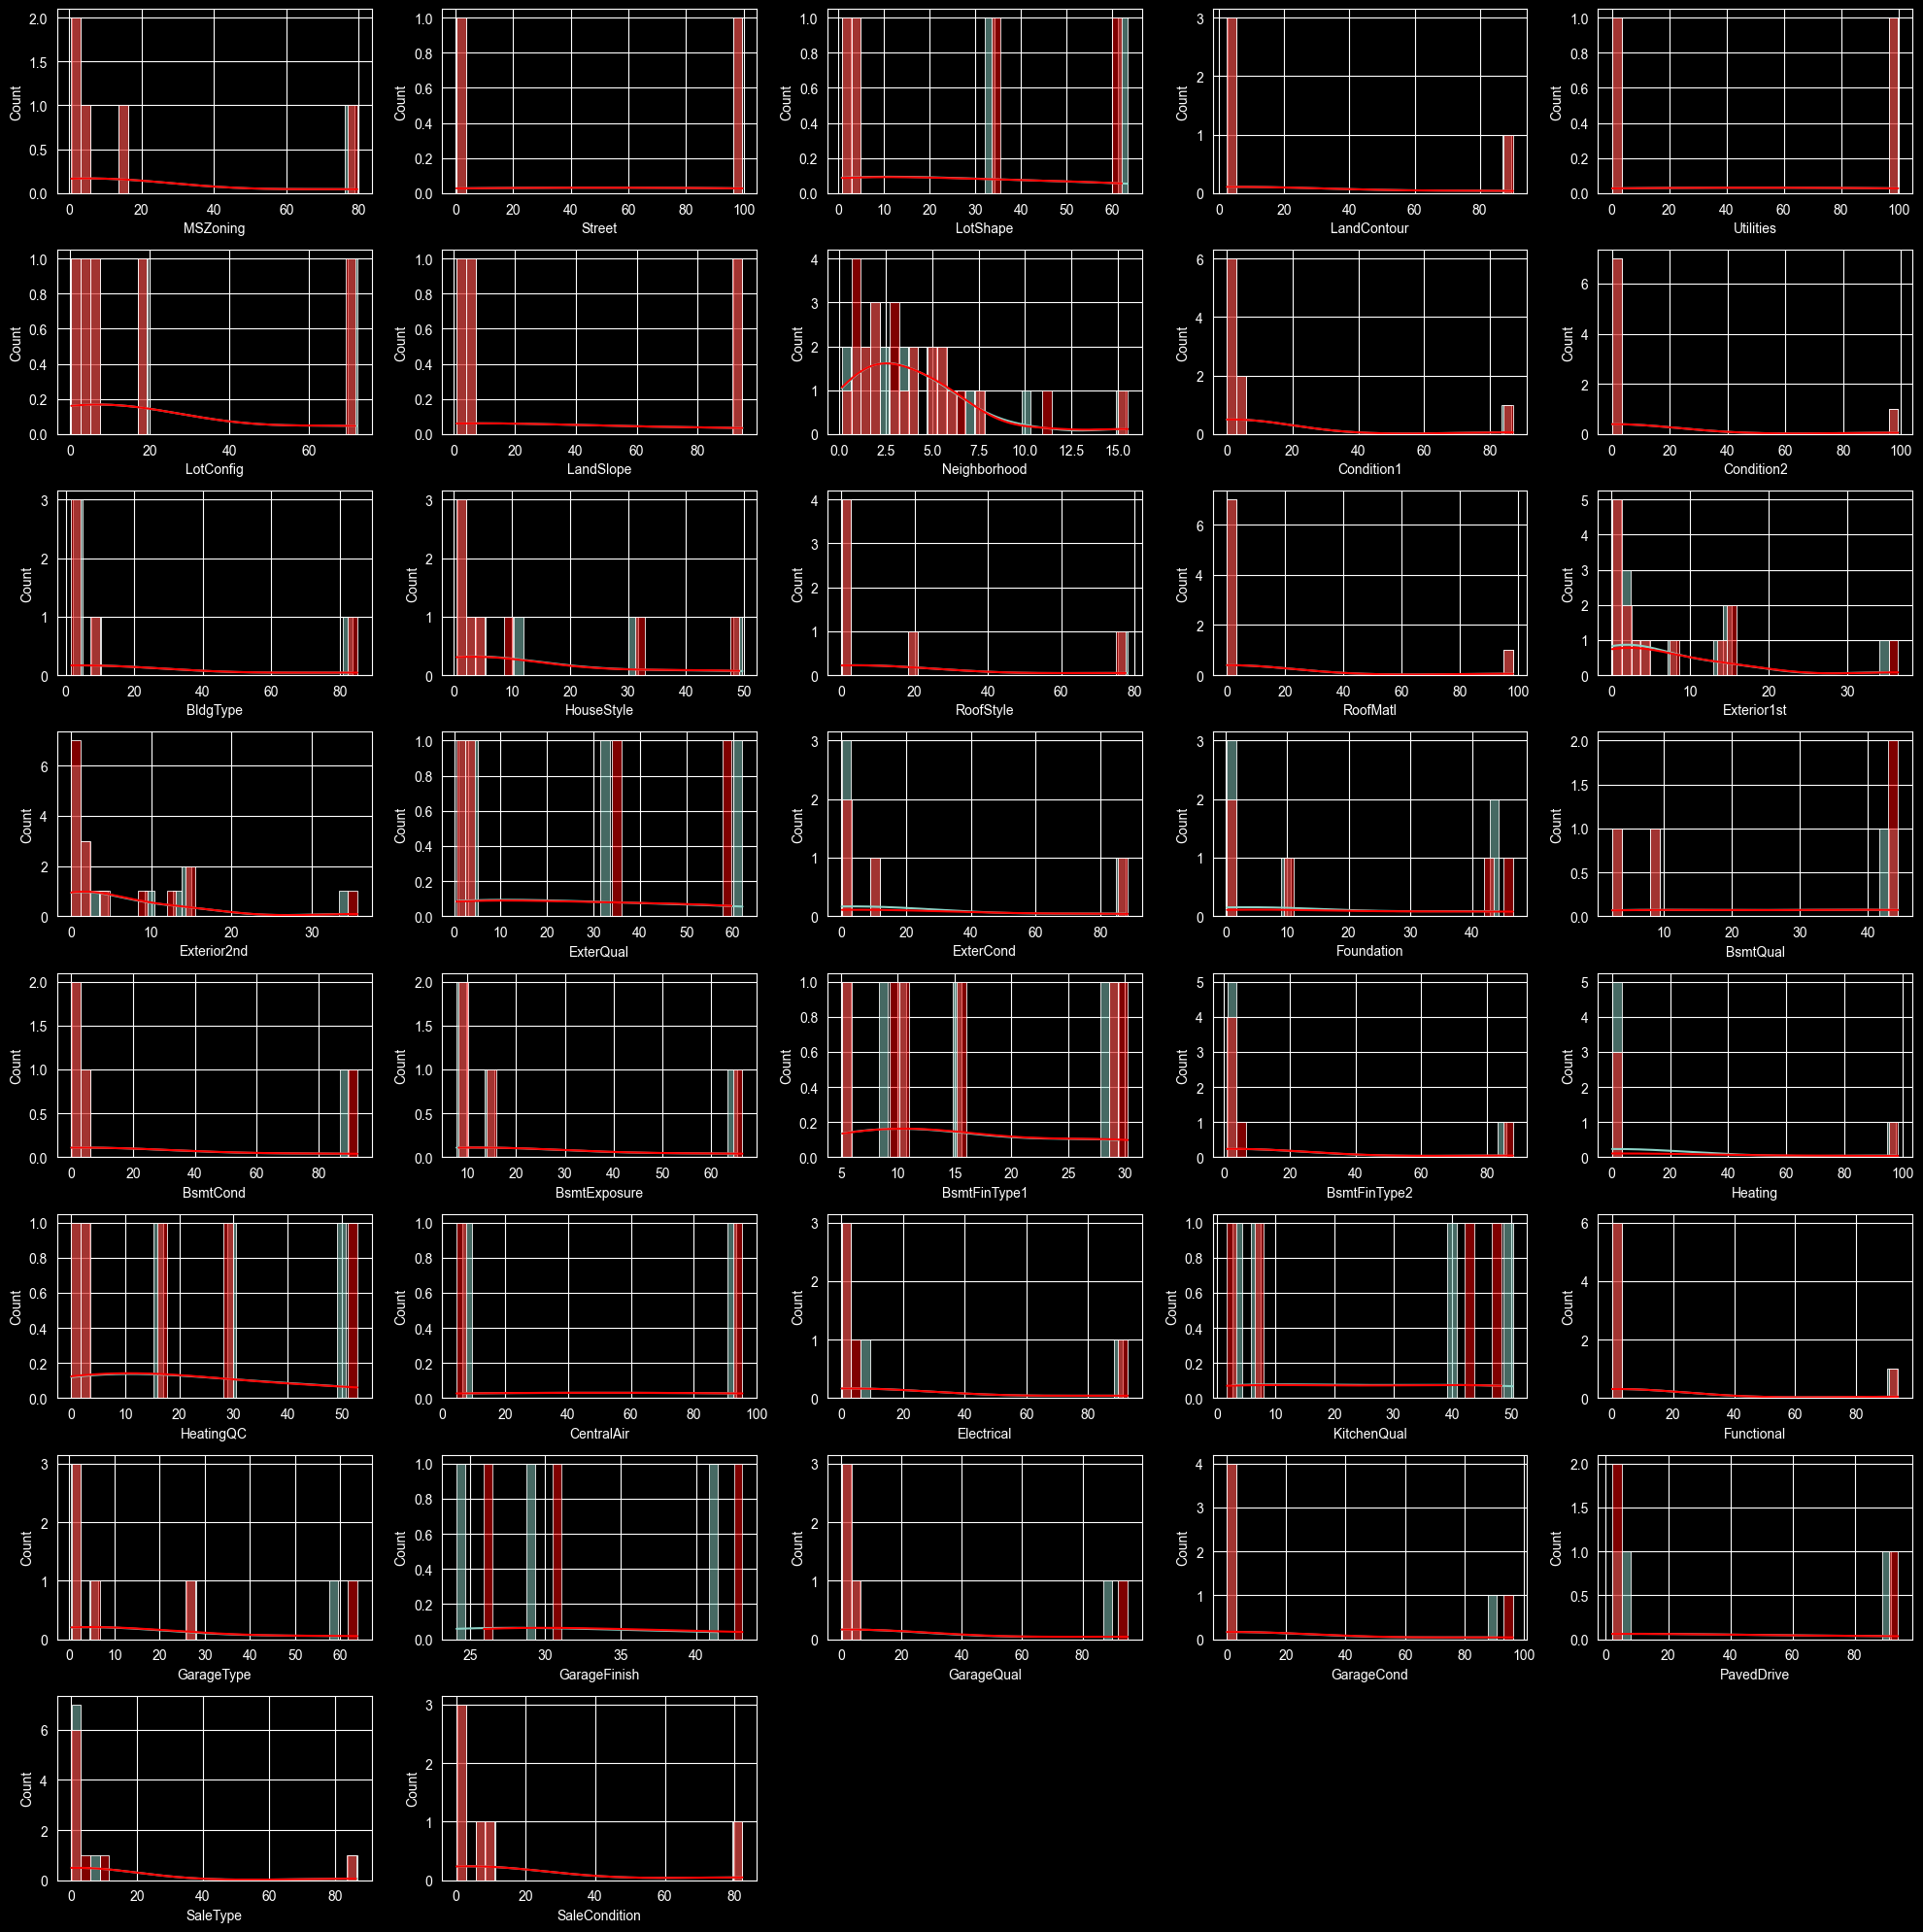

In [30]:
plt.figure(figsize = (20, 20))
for i, var in enumerate(df_cat_clms):
    ax = plt.subplot(8, 5, i+1)
    After = df_cat_clms[var].value_counts() / df_cat_clms.shape[0] * 100
    Before = df[var].value_counts() / df.shape[0] * 100
    sns.histplot(Before, bins = 30, legend = True, kde = True, ax = ax)
    sns.histplot(After, bins = 30, color = "Red", legend = True, kde = True, ax = ax)
    ax.set_xlabel(var) 
plt.tight_layout()
plt.savefig("Histplot visualization of cleaned data for 'train_csv' dataset on object type columns")
plt.show()

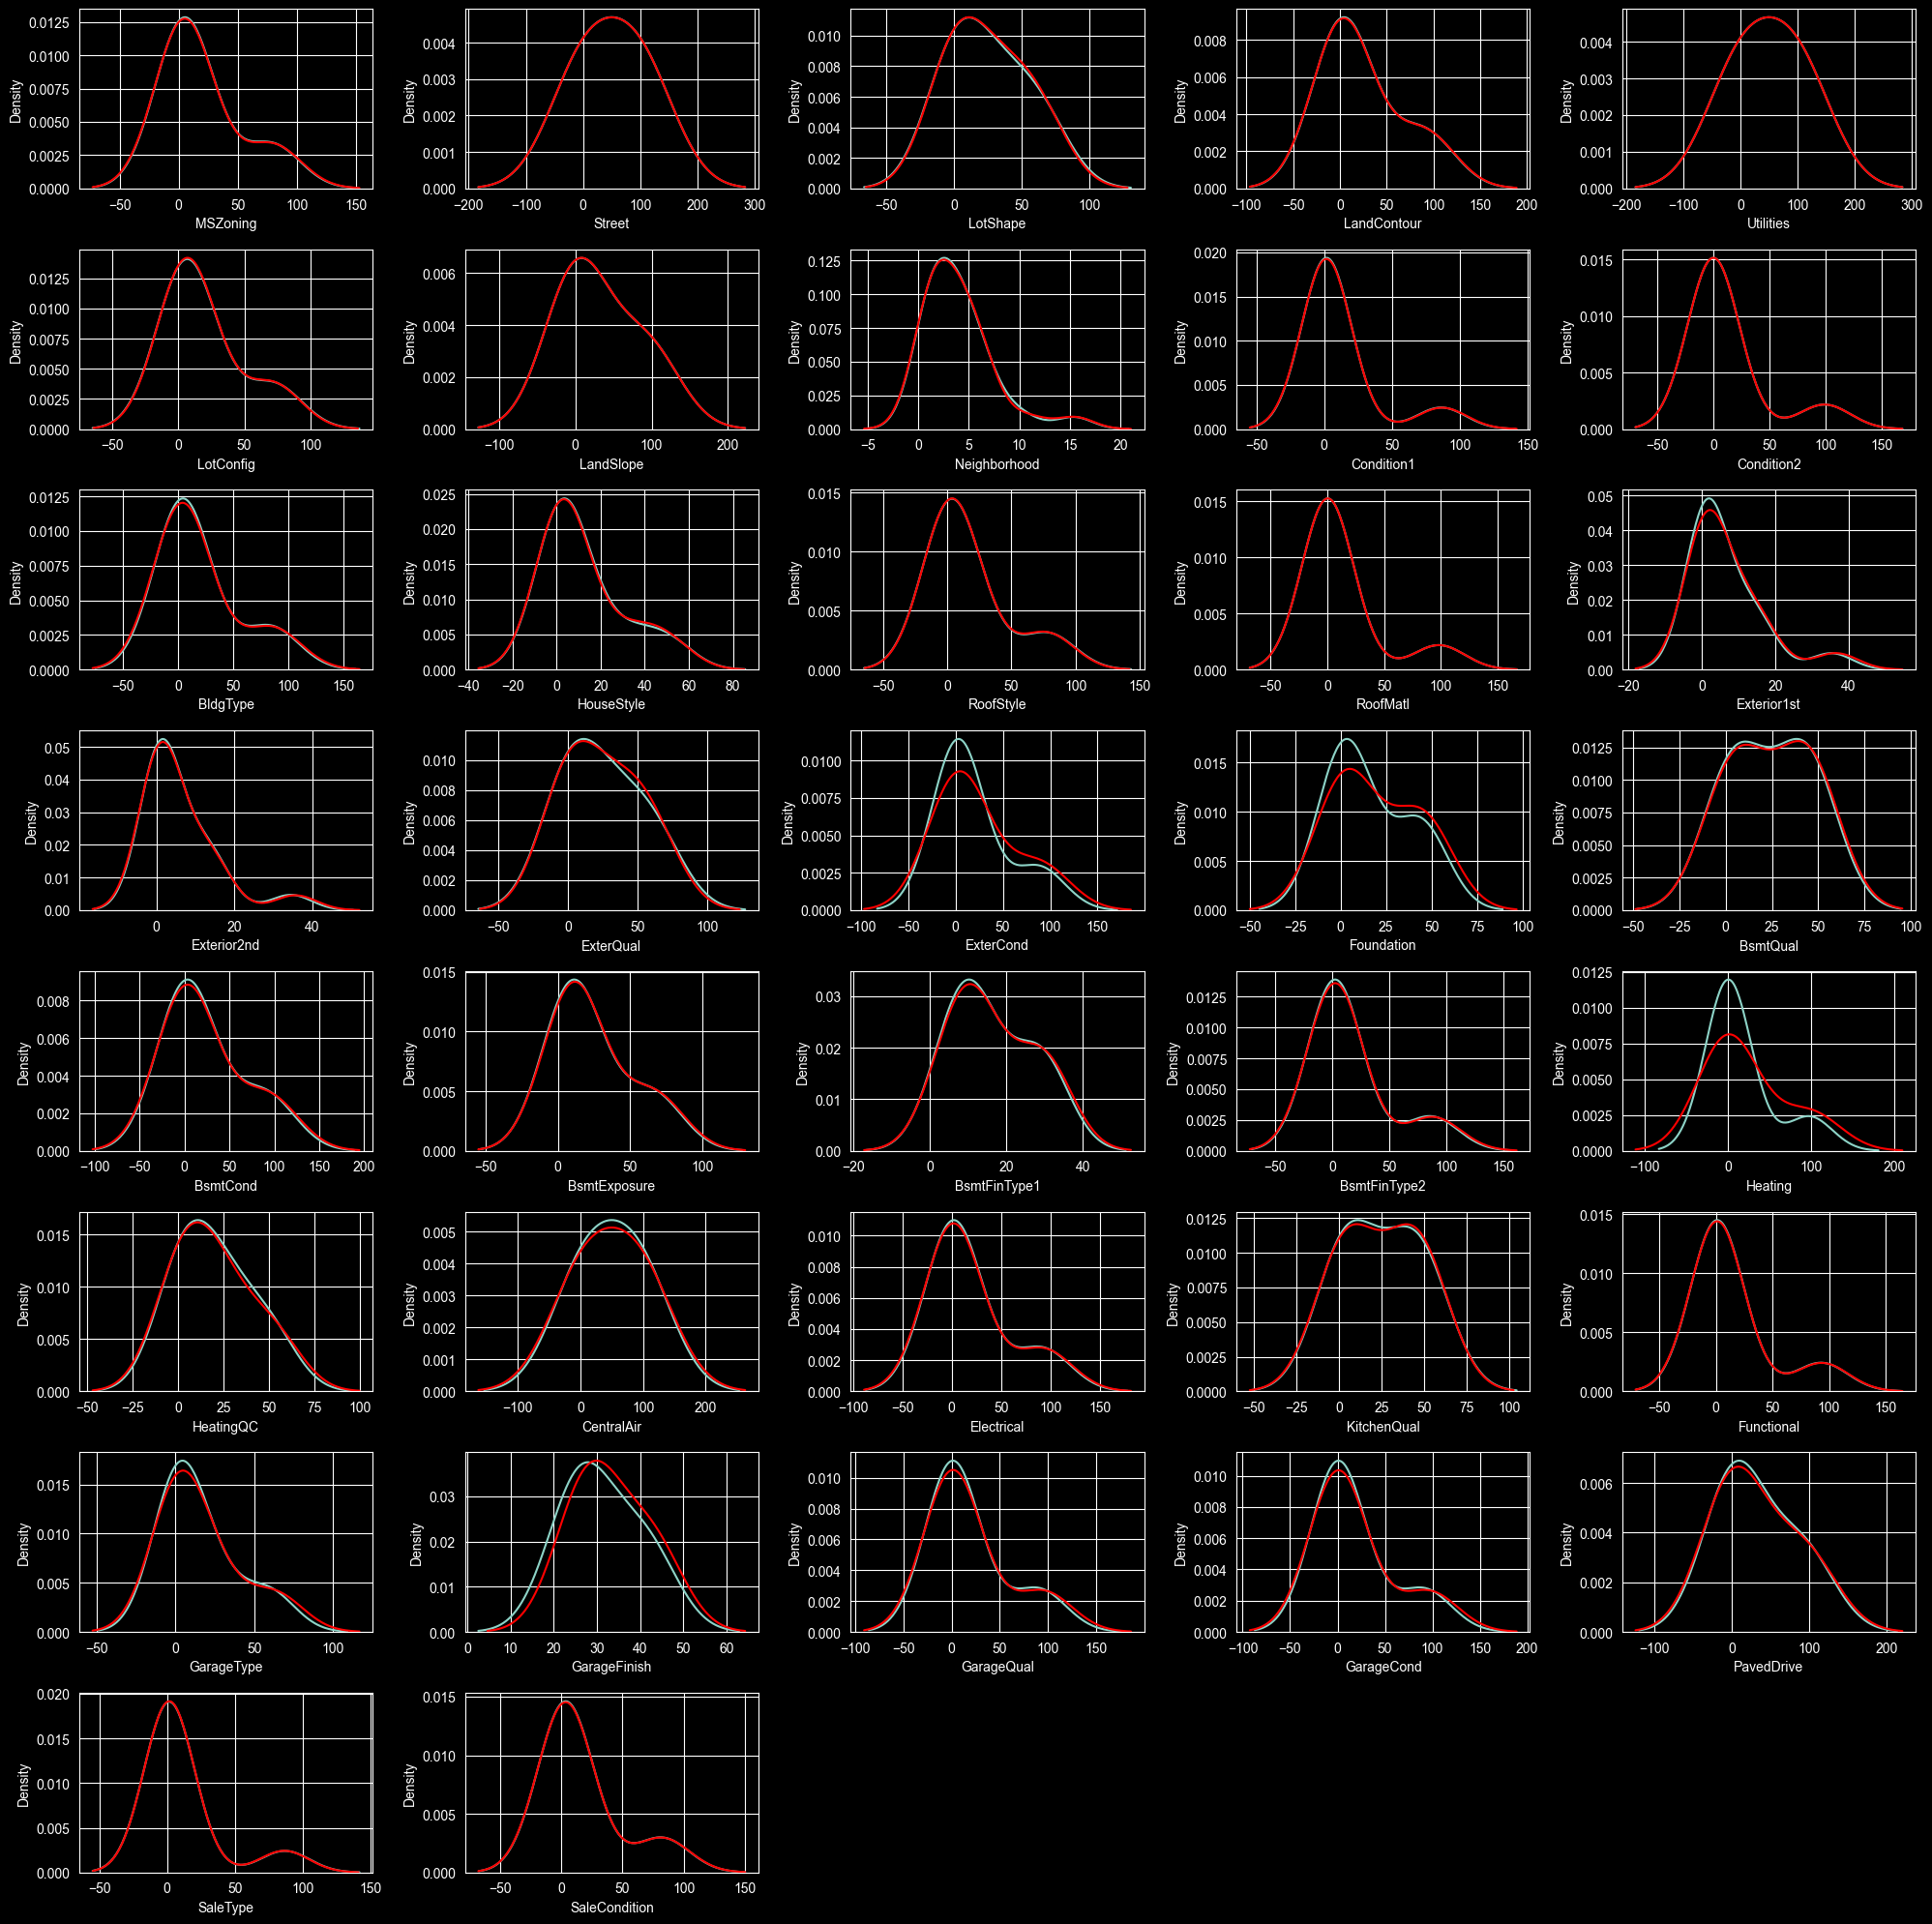

In [31]:
plt.figure(figsize = (20, 20))
for i, var in enumerate(df_cat_clms):
    ax = plt.subplot(8, 5, i+1)
    After = df_cat_clms[var].value_counts() / df_cat_clms.shape[0] * 100
    Before = df[var].value_counts() / df.shape[0] * 100
    sns.kdeplot(Before, ax = ax)
    sns.kdeplot(After, color = "Red", ax = ax)
    ax.set_xlabel(var) 
plt.tight_layout()
plt.savefig("Kdeplot visualization of cleaned data for 'train_csv' dataset on object type columns")
plt.show()

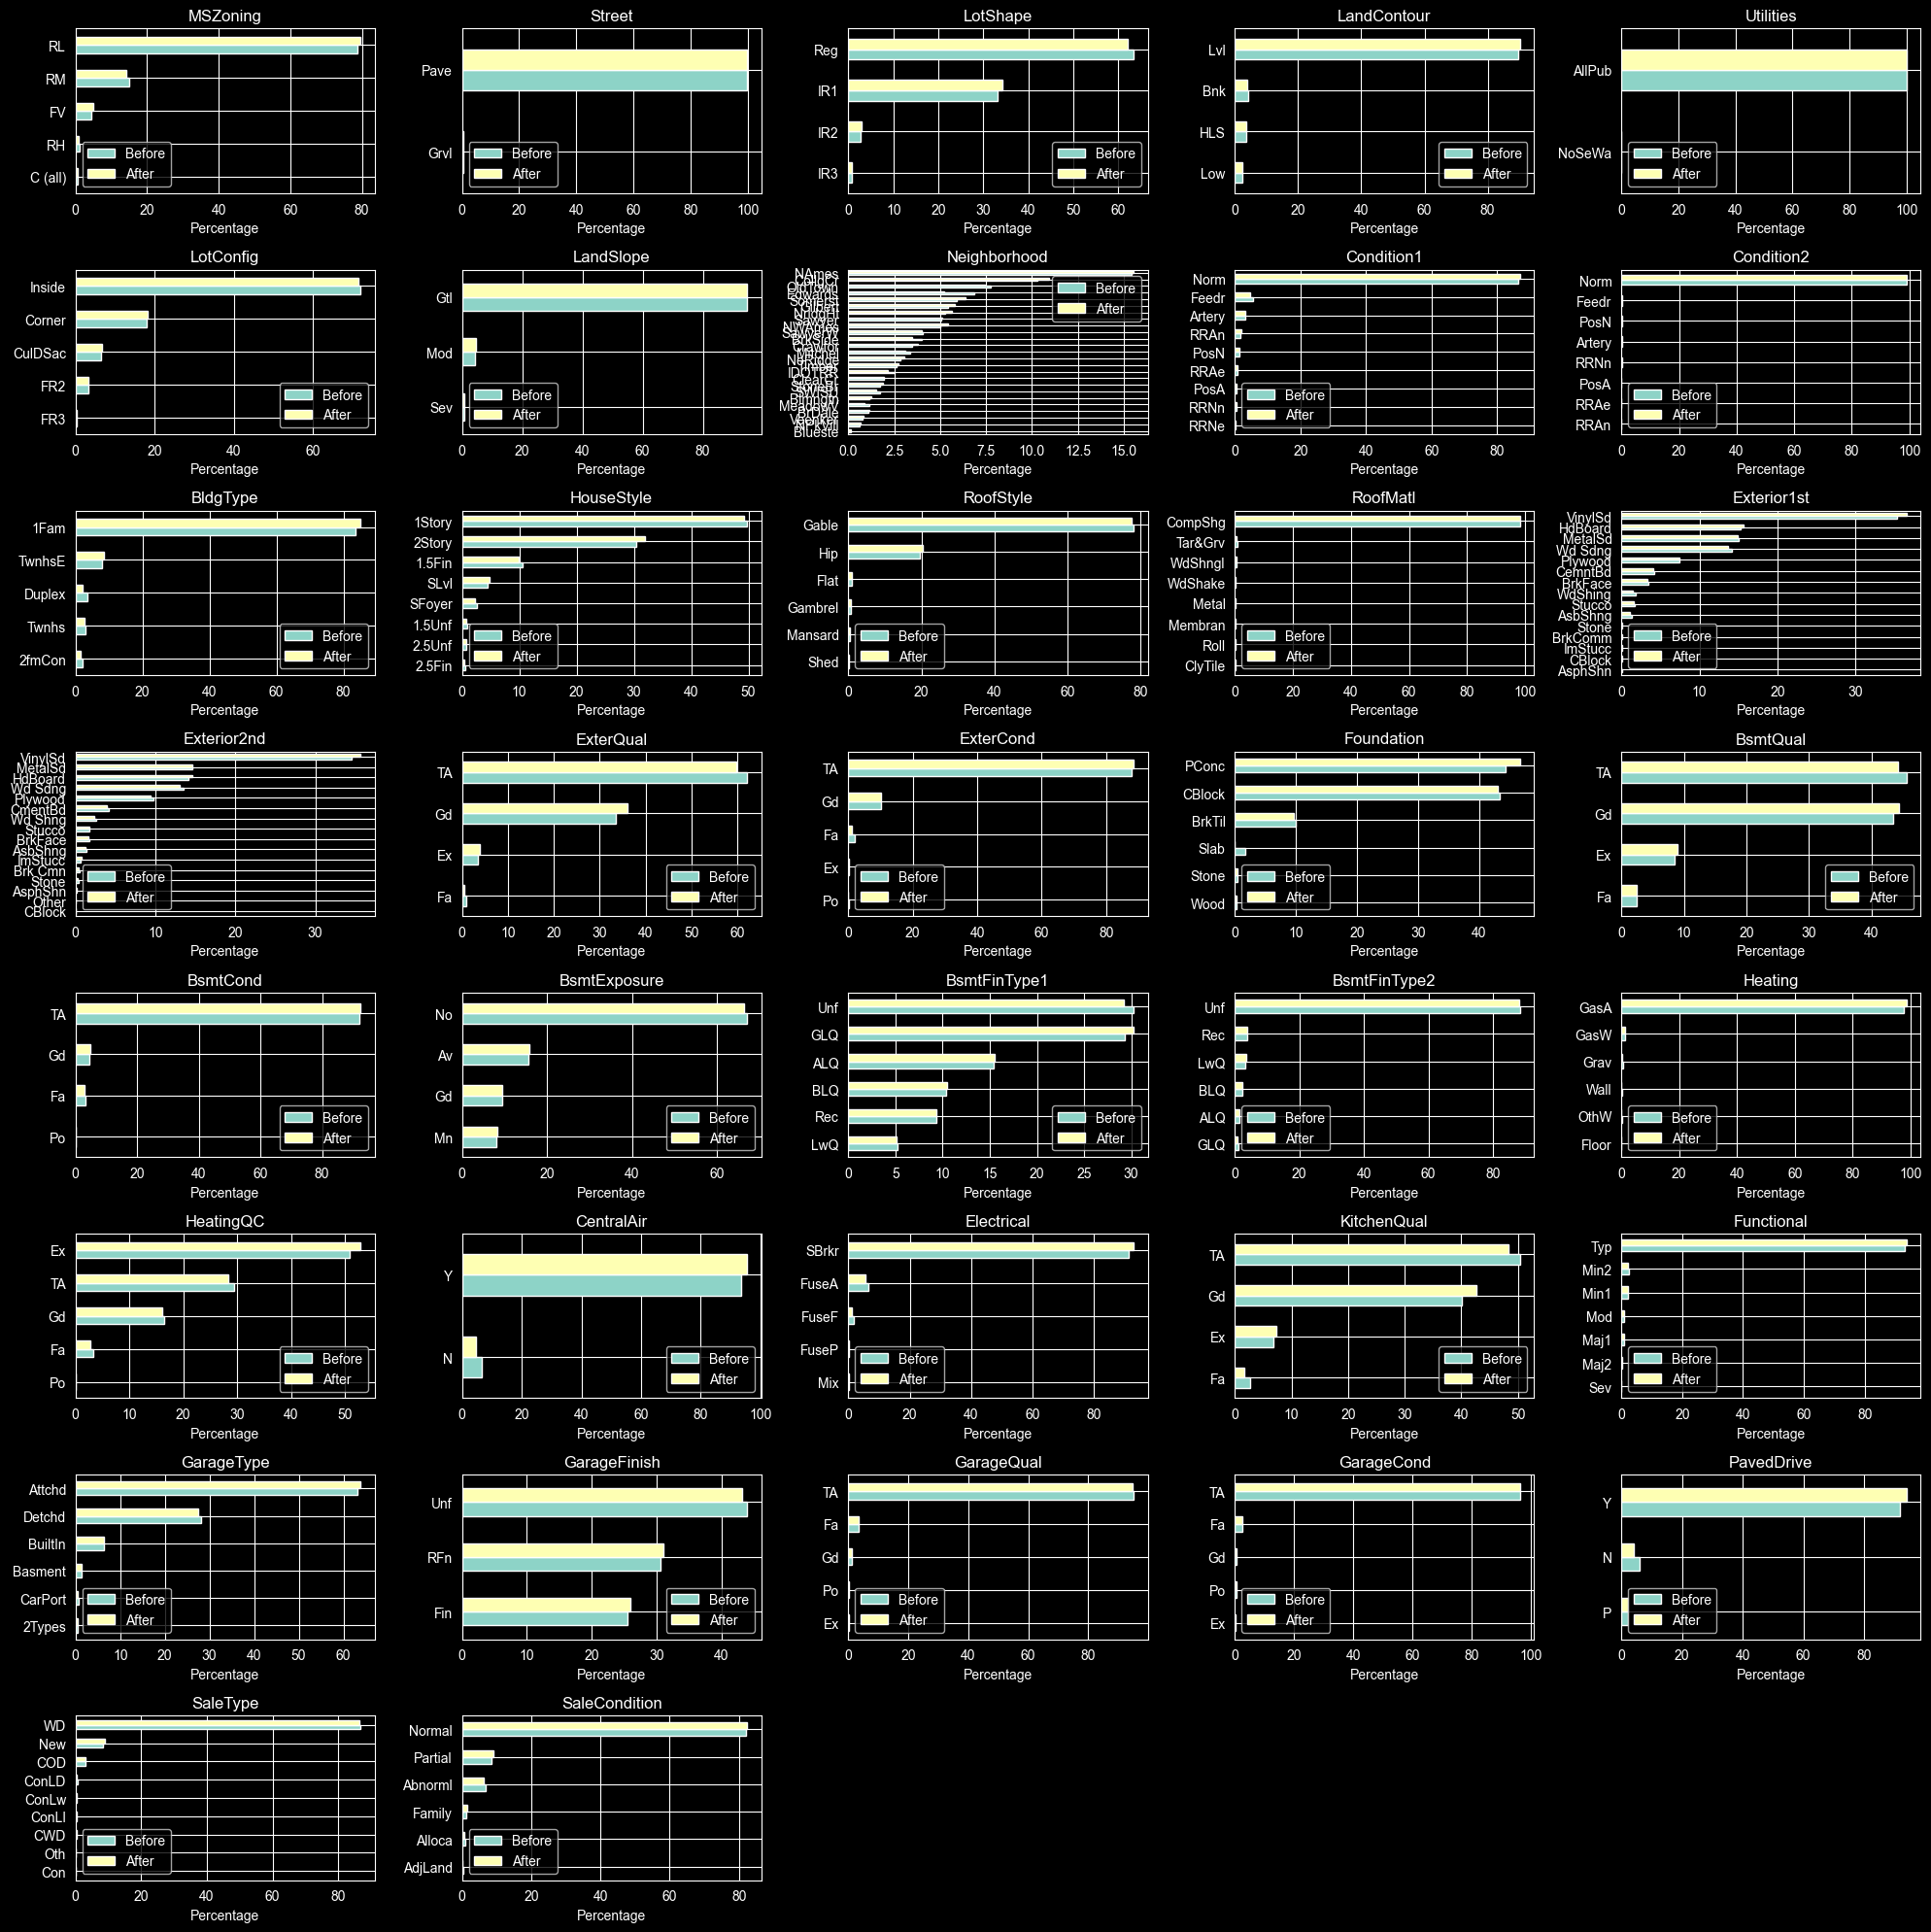

In [32]:
plt.figure(figsize=(20, 20))

for i, var in enumerate(df_cat_clms):
    ax = plt.subplot(8, 5, i+1)
    
    # compute percentage distributions
    before = df[var].value_counts(normalize=True) * 100
    after = df_cat_clms[var].value_counts(normalize=True) * 100
    
    # combine into one dataframe
    compare = pd.DataFrame({
        "Before": before,
        "After": after
    }).fillna(0)
    
    # sort for better readability
    compare = compare.sort_values(by="Before", ascending=True)
    
    # plot horizontal bars
    compare.plot(kind="barh", ax=ax)
    
    # labels
    ax.set_title(var)
    ax.set_xlabel("Percentage")
    ax.set_ylabel("")
    
plt.tight_layout()
plt.savefig("Barplot visualization of cleaned data for 'train_csv' dataset on object type columns")
plt.show()

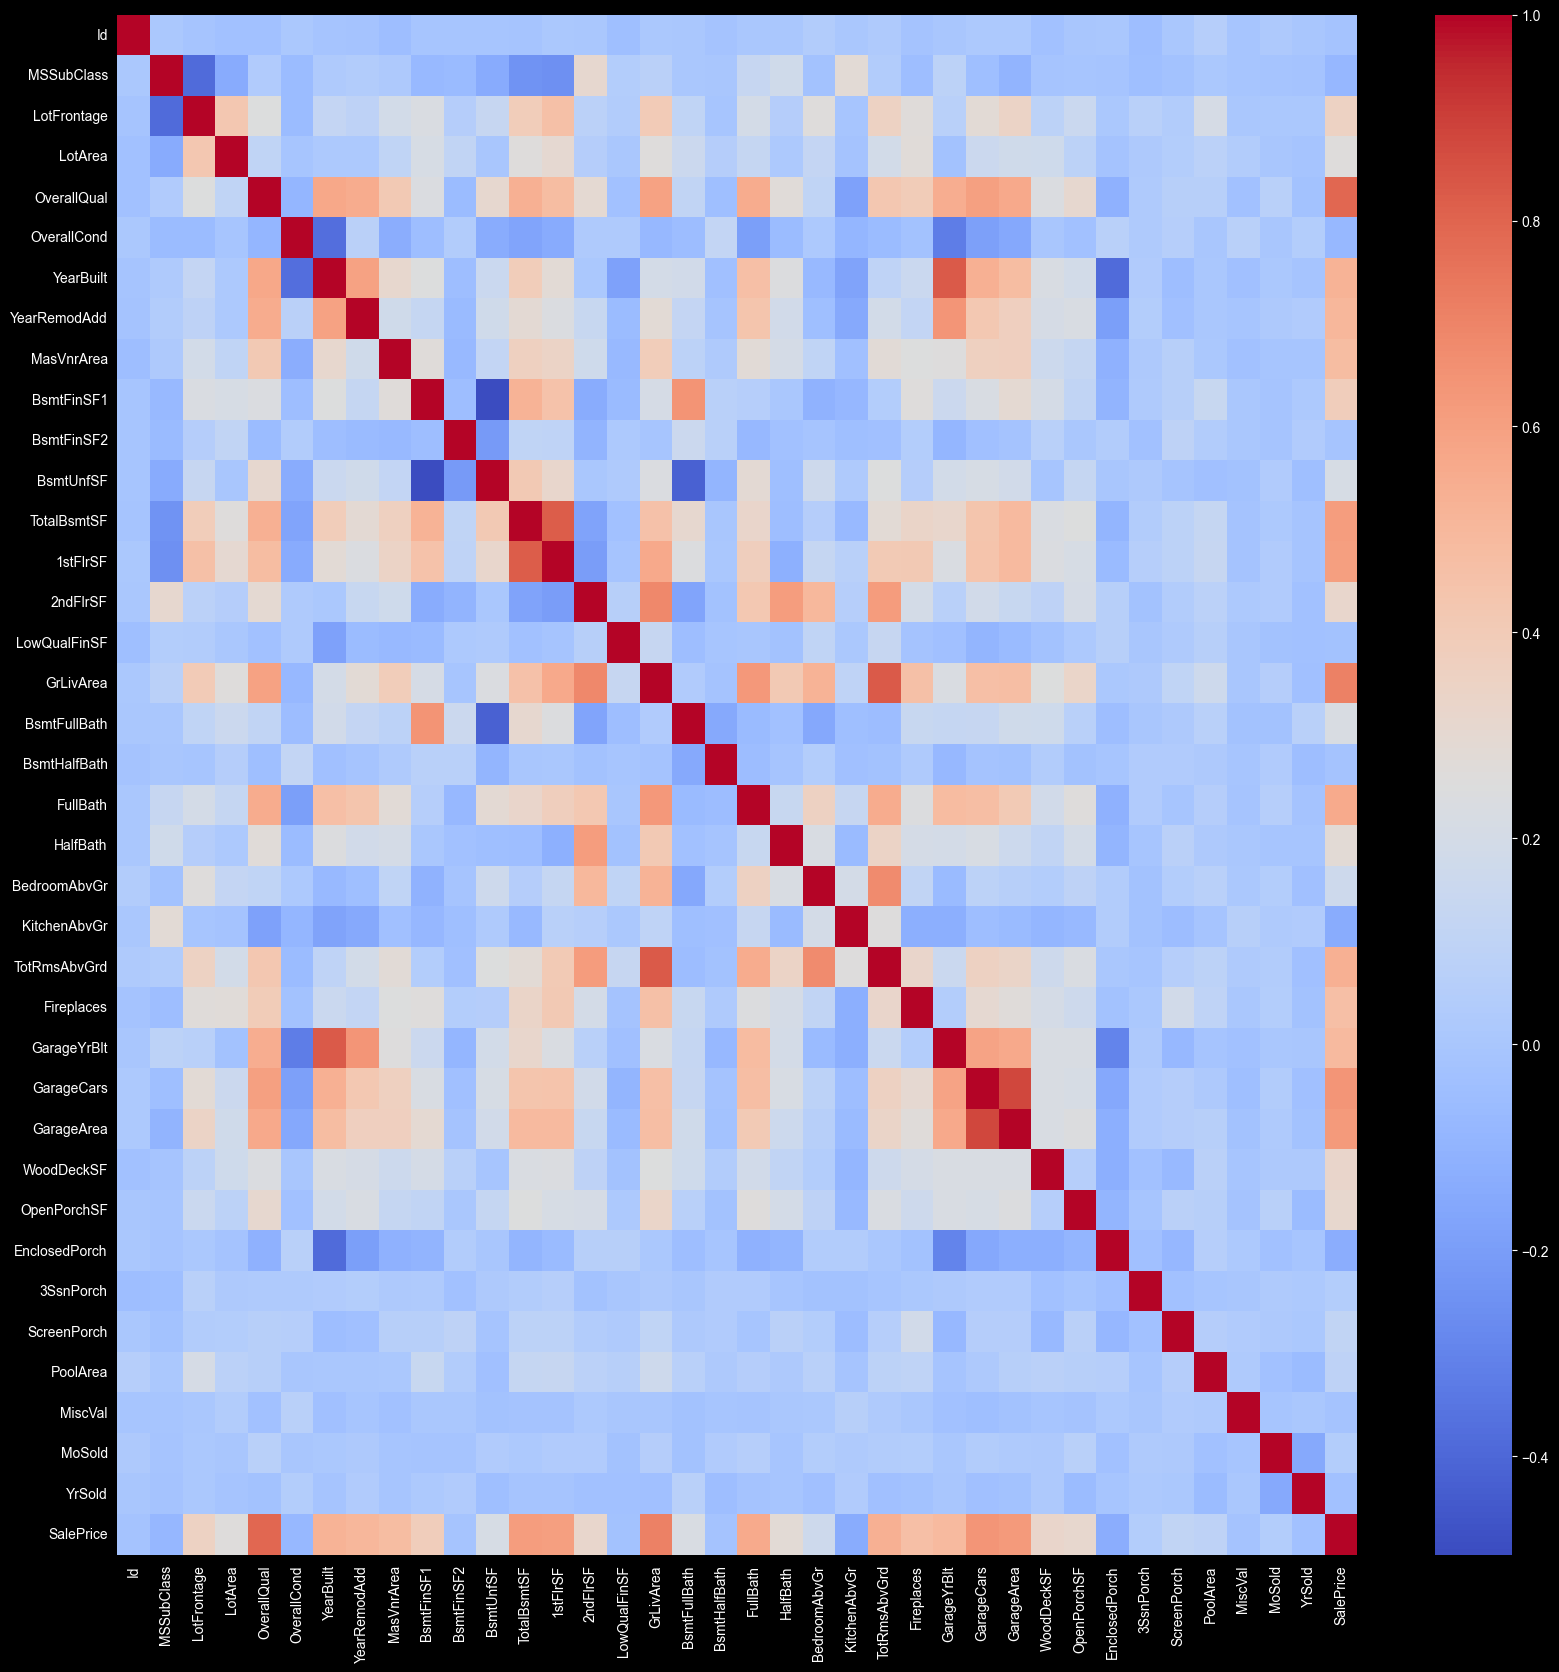

In [33]:
plt.figure(figsize = (20, 20))
sns.heatmap(df.select_dtypes(include = ["int64", "float64"]).corr(), cmap = "coolwarm")
plt.show()